<a href="https://colab.research.google.com/github/basnaa1212/anime_gan/blob/main/anime_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA version: 12.8
CUDA available: True
GPU count: 1
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
import sys
print(sys.executable)

c:\basna\.venv\Scripts\python.exe


In [ ]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
import torch
print(torch.__file__)

c:\basna\.venv\Lib\site-packages\torch\__init__.py


In [ ]:
%pip uninstall -y torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import importlib.util

print(importlib.util.find_spec("torch"))

ModuleSpec(name='torch', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001E8B48CBA70>, origin='c:\\basna\\.venv\\Lib\\site-packages\\torch\\__init__.py', submodule_search_locations=['c:\\basna\\.venv\\Lib\\site-packages\\torch'])


In [ ]:
import sys
print(sys.executable)

c:\basna\.venv\Scripts\python.exe


In [ ]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
import os
import zipfile
#from tqdm import tqdm

import os
import random

In [ ]:
os.getcwd()

'c:\\basna'

In [ ]:
path = "anime_images"
print(os.path.exists(path))

False


In [ ]:
import os
import random
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn

ModuleNotFoundError: No module named 'torchvision'

In [ ]:
dataset_path = "C:/Users/Arjun/Downloads/anime_images"

image_paths = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".png", ".jpg", ".jpeg")):

            image_paths.append(os.path.join(root, file))

print("Total Images :", len(image_paths))

Total Images : 63565


Image Size : (66, 66)
Image Mode : RGB


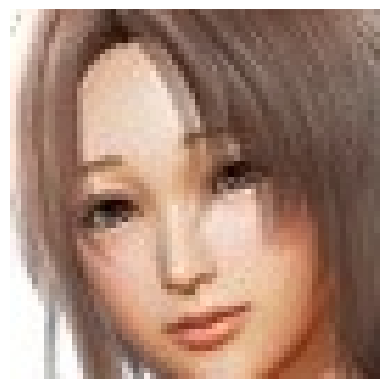

In [ ]:
sample_path = random.choice(image_paths)

img = Image.open(sample_path)

print("Image Size :", img.size)

print("Image Mode :", img.mode)

plt.imshow(img)

plt.axis("off")

plt.show()

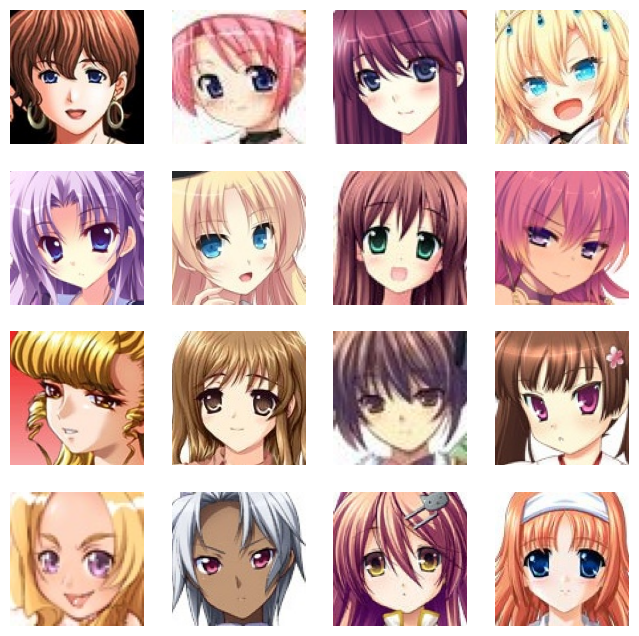

In [ ]:
fig, axes = plt.subplots(4,4, figsize=(8,8))

for ax in axes.flatten():

    path = random.choice(image_paths)

    img = Image.open(path)

    ax.imshow(img)

    ax.axis("off")

plt.show()

In [ ]:
path = random.choice(image_paths)

img = np.array(Image.open(path))

print(img.shape)

print(img.min())

print(img.max())

print(img.dtype)

(96, 96, 3)
0
255
uint8


In [ ]:
image_size = (64,64)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [ ]:
dataset = DataLoader(ImageFolder(dataset_path, transform=transform), batch_size=64, shuffle=True,num_workers=2)

In [ ]:
real_images,labels = next(iter(dataset))

In [ ]:
print("Batch Shape :", real_images.shape)
print("Data Type   :", real_images.dtype)
print("Minimum     :", real_images.min())
print("Maximum     :", real_images.max())

Batch Shape : torch.Size([64, 3, 64, 64])
Data Type   : torch.float32
Minimum     : tensor(-1.)
Maximum     : tensor(1.)


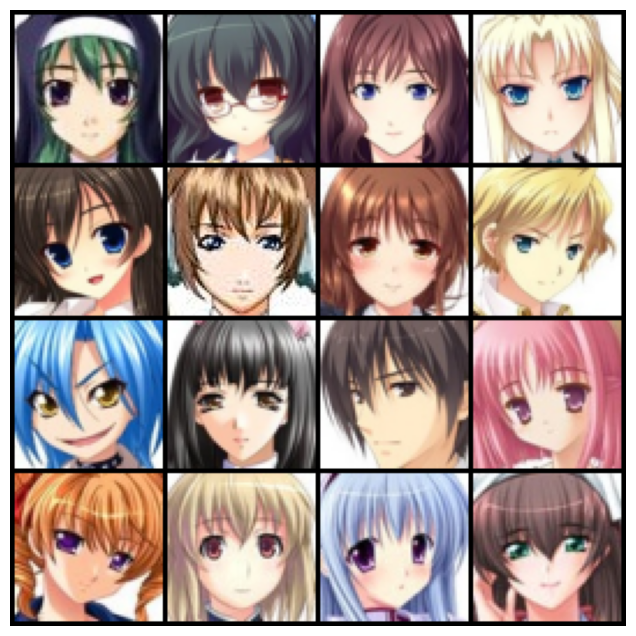

In [ ]:
grid = torchvision.utils.make_grid(
    real_images[:16],
    nrow=4,
    normalize=True
)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

In [ ]:
class Generator(nn.Module):
  def __init__(self,noice_dimension=128):
    super().__init__()
    self.model= nn.Sequential(

        #Layer 1
        nn.ConvTranspose2d(
            in_channels=noice_dimension,
            out_channels =512,
            kernel_size=4,
            stride=1,
            padding=0,
            bias=False
        ),
        nn.BatchNorm2d(512),
        nn.ReLU(True),

        #Layer 2
        nn.ConvTranspose2d(
        in_channels=512,
        out_channels=256,
        kernel_size=4,
        stride=2,
        padding=1,
        bias=False
      ),

      nn.BatchNorm2d(256),

      nn.ReLU(True),

      #Layer 2
      nn.ConvTranspose2d(
        in_channels=256,
        out_channels=128,
        kernel_size=4,
        stride=2,
        padding=1,
        bias=False
      ),


      nn.BatchNorm2d(128),
      nn.ReLU(True),

        #layer 4
      nn.ConvTranspose2d(
      in_channels=128,
      out_channels=64,
      kernel_size=4,
      stride=2,
      padding=1,
      bias=False
      ),

      nn.BatchNorm2d(64),
      nn.ReLU(True),

        #layer 5
      nn.ConvTranspose2d(
      in_channels=64,
      out_channels=3,
      kernel_size=4,
      stride=2,
      padding=1,
      bias=False
      ),

      #Final layer use tanh since gan producec valu form -1 to 1
      nn.Tanh()
    )

  def forward(self,x):
        return self.model(x)

In [ ]:
generator = Generator()

noise = torch.randn(8,128,1,1)

fake_info_for_image = generator(noise)

print(fake_info_for_image.shape)

torch.Size([8, 3, 64, 64])


In [ ]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),


            nn.Conv2d(
                in_channels=256,
                out_channels=512,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                in_channels=512,
                out_channels=1,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False
            ),



        )



    def forward(self,x):
      return self.model(x)

In [ ]:
discriminator = Discriminator()

descriminator_out = discriminator(fake_info_for_image)

print(descriminator_out.shape)

torch.Size([8, 1, 1, 1])


In [ ]:
noise = torch.randn(64,128,1,1)
fake_image= generator(noise)

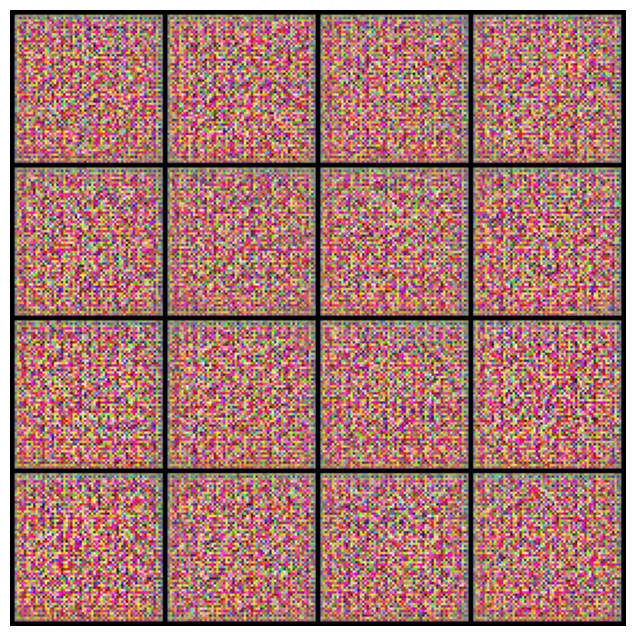

In [ ]:
grid = torchvision.utils.make_grid(
    fake_image[:16],
    nrow=4,
    normalize=True
)
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

In [ ]:

predictions = discriminator(real_images)
predictions

tensor([[[[-0.2793]]],


        [[[ 0.0659]]],


        [[[-0.3761]]],


        [[[-0.0938]]],


        [[[-0.3486]]],


        [[[-0.4724]]],


        [[[-0.2697]]],


        [[[-0.2915]]],


        [[[-0.7753]]],


        [[[-0.5668]]],


        [[[-0.3632]]],


        [[[ 0.2102]]],


        [[[ 0.1756]]],


        [[[ 0.0273]]],


        [[[-0.4965]]],


        [[[-0.8230]]],


        [[[-0.1238]]],


        [[[ 0.2278]]],


        [[[-0.3343]]],


        [[[-0.1290]]],


        [[[ 0.2178]]],


        [[[ 0.2172]]],


        [[[-0.1020]]],


        [[[ 0.0553]]],


        [[[ 0.3847]]],


        [[[-0.1311]]],


        [[[-0.4980]]],


        [[[ 0.0380]]],


        [[[-0.0135]]],


        [[[ 0.4634]]],


        [[[-0.4527]]],


        [[[ 0.1480]]],


        [[[ 0.1199]]],


        [[[-0.0454]]],


        [[[-0.0827]]],


        [[[-0.0996]]],


        [[[-0.1806]]],


        [[[-0.7301]]],


        [[[ 0.1033]]],


        [[[-0.9187]]],




In [ ]:
prediction_on_fake_images = discriminator(fake_image)
prediction_on_fake_images

tensor([[[[-0.2965]]],


        [[[ 0.1929]]],


        [[[-0.2220]]],


        [[[-0.4595]]],


        [[[-0.0497]]],


        [[[-0.5326]]],


        [[[-0.6556]]],


        [[[-0.5393]]],


        [[[-0.3498]]],


        [[[-0.3532]]],


        [[[-0.0437]]],


        [[[-0.4403]]],


        [[[-0.7381]]],


        [[[-0.8052]]],


        [[[-0.9143]]],


        [[[ 0.4667]]],


        [[[-0.7012]]],


        [[[ 0.1028]]],


        [[[-0.3447]]],


        [[[ 0.0206]]],


        [[[-0.4564]]],


        [[[ 0.2634]]],


        [[[-0.4299]]],


        [[[-0.1668]]],


        [[[-0.2926]]],


        [[[-0.4815]]],


        [[[-0.2880]]],


        [[[-0.1956]]],


        [[[ 0.2145]]],


        [[[-0.1440]]],


        [[[ 0.0701]]],


        [[[-0.7214]]],


        [[[-0.0522]]],


        [[[-0.5405]]],


        [[[-0.8570]]],


        [[[-0.6316]]],


        [[[-0.3796]]],


        [[[-0.5106]]],


        [[[-0.0355]]],


        [[[-0.1975]]],




In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
optimizerG = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [ ]:
optimizerD = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.00005,
    betas=(0.5,0.999)
)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
#Fixed noice
fixed_noise = torch.randn(64,128,1,1).to(device)

In [ ]:
real_images = real_images.to(device)

In [ ]:
batch_size = 64

In [ ]:
noise = torch.randn(batch_size,128,1,1,device=device)

fake_images = generator(noise)

In [ ]:
real_output = discriminator(real_images)

fake_output = discriminator(fake_images.detach())

In [ ]:
real_labels = torch.full(
    (batch_size,1,1,1),
    0.9,
    device=device
)

fake_labels = torch.zeros(
    batch_size,1,1,1,
    device=device
)

In [ ]:
real_labels = torch.ones_like(real_output)
fake_labels = torch.zeros_like(fake_output)

loss_real = criterion(real_output, real_labels)

loss_fake = criterion(fake_output, fake_labels)

lossD = loss_real + loss_fake

In [ ]:
EPOCHS = 100
LATENT_DIM = 128

In [ ]:
import os

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("generated", exist_ok=True)

In [ ]:
import torchvision.utils as vutils

fixed_noise = torch.randn(
    16,
    LATENT_DIM,
    1,
    1,
    device=device
)


def save_images(epoch):

    generator.eval()

    with torch.no_grad():
        fake = generator(fixed_noise)

    vutils.save_image(
        fake,
        f"generated/epoch_{epoch}.png",
        normalize=True,
        nrow=4
    )

    generator.train()

In [ ]:
for epoch in range(EPOCHS):

    for real_images, _ in dataset:

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, 1, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, 1, 1, device=device)

        # ======================
        # Train Discriminator
        # ======================

        optimizerD.zero_grad()

        # Real images
        real_outputs = discriminator(real_images)
        d_real_loss = criterion(real_outputs, real_labels)

        # Fake images
        noise = torch.randn(batch_size,LATENT_DIM , 1, 1, device=device)

        fake_images = generator(noise)

        fake_outputs = discriminator(fake_images.detach())
        d_fake_loss = criterion(fake_outputs, fake_labels)

        d_loss = d_real_loss + d_fake_loss

        d_loss.backward()
        optimizerD.step()

        # ======================
        # Train Generator
        # ======================

        optimizerG.zero_grad()

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizerG.step()
    save_images(epoch+1)
    torch.save(
    {
        "epoch": epoch,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizerG": optimizerG.state_dict(),
        "optimizerD": optimizerD.state_dict(),
    },
    f"checkpoints/gan_epoch_{epoch+1}.pth"
)
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

    # Check discriminator confidence
    with torch.no_grad():
        fake_score = discriminator(fake_images).mean()

    print(f"Fake Score: {fake_score.item():.4f}")

Epoch [1/100] D Loss: 0.1519 G Loss: 6.6206
Fake Score: -6.6186
Epoch [2/100] D Loss: 0.2318 G Loss: 3.6877
Fake Score: -3.6503
Epoch [3/100] D Loss: 0.0985 G Loss: 6.6561
Fake Score: -6.6545
Epoch [4/100] D Loss: 0.2790 G Loss: 8.6372
Fake Score: -8.6368
Epoch [5/100] D Loss: 0.0242 G Loss: 5.5634
Fake Score: -5.5580
Epoch [6/100] D Loss: 0.8260 G Loss: 7.7184
Fake Score: -7.7172
Epoch [7/100] D Loss: 2.1074 G Loss: 0.9264
Fake Score: 0.1979
Epoch [8/100] D Loss: 0.0626 G Loss: 7.9370
Fake Score: -7.9366
Epoch [9/100] D Loss: 2.3401 G Loss: 3.3764
Fake Score: -3.2860
Epoch [10/100] D Loss: 0.9100 G Loss: 3.0513
Fake Score: -2.9629
Epoch [11/100] D Loss: 0.1797 G Loss: 6.2933
Fake Score: -6.2879
Epoch [12/100] D Loss: 0.4519 G Loss: 3.2221
Fake Score: -3.1678
Epoch [13/100] D Loss: 0.1722 G Loss: 8.1320
Fake Score: -8.1316
Epoch [14/100] D Loss: 0.0781 G Loss: 5.3544
Fake Score: -5.3480
Epoch [15/100] D Loss: 0.3279 G Loss: 16.5835
Fake Score: -16.5835
Epoch [16/100] D Loss: 0.0315 G L

KeyboardInterrupt: 